# Cell 1 — Imports

In [11]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

# Cell 2 — Load master data (từ file local sau khi clone)

In [12]:

master_df = pd.read_csv('data/master_data.csv')
print(f"Master data shape: {master_df.shape}")
master_df.head()

Master data shape: (100, 5)


,product_id,product_name,category,production_line,monthly_output
0,1,Product A,Category 1,Line-1,2109
1,2,Product B,Category 1,Line-1,1028
2,3,Product C,Category 1,Line-1,851
3,4,Product D,Category 1,Line-1,2318
4,5,Product E,Category 1,Line-1,1363


# Cell 3 — Fetch defect records qua HTTP (KHÔNG đọc file local)


In [13]:
API_URL = "https://raw.githubusercontent.com/phongtdt/RFID_Data-Analyst_Case-Study-Test-Jun/main/mock-api/defect_records.json"

response = requests.get(API_URL)
response.raise_for_status()  # raise lỗi nếu request thất bại

defect_df = pd.DataFrame(response.json())
print(f"Defect records shape: {defect_df.shape}")
defect_df

Defect records shape: (1090, 8)


,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,186,21,Functional,1/11/2024,Component,Minor,Manual Testing,174.99
1,900,84,Functional,6/15/2024,Surface,Critical,Manual Testing,198.59
2,999,96,Functional,4/12/2024,Internal,Minor,Manual Testing,903.45
3,338,31,Cosmetic,2/5/2024,Component,Minor,Manual Testing,336.90
4,804,13,Functional,5/2/2024,Surface,Minor,Visual Inspection,598.25
...,...,...,...,...,...,...,...,...
1085,943,79,Structural,4/16/2024,Internal,Critical,Manual Testing,233.17
1086,765,70,Cosmetic,3/13/2024,Component,Moderate,Visual Inspection,382.76
1087,515,3,Functional,5/22/2024,Internal,Critical,Manual Testing,237.26
1088,293,44,Functional,1/10/2024,Internal,Critical,Automated Testing,500.75


# Cell 4 — Tổng quan master_df


In [14]:
print("=== MASTER DATA ===")
print(master_df.info())
print("\nNull values:\n", master_df.isnull().sum())
print("\nDuplicates:", master_df.duplicated().sum())
print("\nUnique values:")
for col in ['category', 'production_line']:
    print(f"  {col}: {master_df[col].unique()}")

=== MASTER DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   product_id       100 non-null    int64
 1   product_name     100 non-null    str  
 2   category         100 non-null    str  
 3   production_line  100 non-null    str  
 4   monthly_output   100 non-null    int64
dtypes: int64(2), str(3)
memory usage: 6.5 KB
None

Null values:
 product_id         0
product_name       0
category           0
production_line    0
monthly_output     0
dtype: int64

Duplicates: 0

Unique values:
  category: <ArrowStringArray>
['Category 1', 'Category 2', 'Category 3', 'Category 4']
Length: 4, dtype: str
  production_line: <ArrowStringArray>
['Line-1', 'Line-2', 'Line-3', 'Line-4']
Length: 4, dtype: str


# Cell 5 — Tổng quan defect_df


In [15]:
print("=== DEFECT RECORDS ===")
print(defect_df.info())
print("\nNull values:\n", defect_df.isnull().sum())
print("\nDuplicates:", defect_df.duplicated().sum())
print("\nUnique values:")
for col in ['defect_type', 'defect_location', 'severity', 'inspection_method']:
    print(f"  {col}: {defect_df[col].unique()}")

=== DEFECT RECORDS ===
<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   defect_id          1090 non-null   int64  
 1   product_id         1090 non-null   int64  
 2   defect_type        1090 non-null   str    
 3   defect_date        1090 non-null   str    
 4   defect_location    1090 non-null   str    
 5   severity           1090 non-null   str    
 6   inspection_method  1090 non-null   str    
 7   repair_cost        1070 non-null   float64
dtypes: float64(1), int64(2), str(5)
memory usage: 120.4 KB
None

Null values:
 defect_id             0
product_id            0
defect_type           0
defect_date           0
defect_location       0
severity              0
inspection_method     0
repair_cost          20
dtype: int64

Duplicates: 12

Unique values:
  defect_type: <ArrowStringArray>
[    'Functional',       'Cosmetic',     'Structura

# Cell 6 — Fix kiểu dữ liệu


In [16]:
defect_df["defect_date"] = pd.to_datetime(defect_df["defect_date"], format="mixed", dayfirst=False)
defect_df['month'] = defect_df['defect_date'].dt.month
defect_df['month_name'] = defect_df['defect_date'].dt.strftime('%b')  # Jan, Feb...
defect_df['year'] = defect_df['defect_date'].dt.year

print("Date range:", defect_df['defect_date'].min(), "→", defect_df['defect_date'].max())
defect_df[['defect_date', 'month', 'month_name', 'year']].head()

Date range: 2024-01-01 00:00:00 → 2026-06-20 00:00:00


,defect_date,month,month_name,year
0,2024-01-11,1,Jan,2024
1,2024-06-15,6,Jun,2024
2,2024-04-12,4,Apr,2024
3,2024-02-05,2,Feb,2024
4,2024-05-02,5,May,2024


# Cell 7 — Merge


In [17]:
df = defect_df.merge(master_df, on='product_id', how='left')

print(f"Rows sau merge: {len(df)}")
print(f"Null sau merge (kiểm tra join miss):\n{df[master_df.columns].isnull().sum()}")
df.head()

Rows sau merge: 1090
Null sau merge (kiểm tra join miss):
product_id         0
product_name       5
category           5
production_line    5
monthly_output     5
dtype: int64


,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost,month,month_name,year,product_name,category,production_line,monthly_output
0,186,21,Functional,2024-01-11,Component,Minor,Manual Testing,174.99,1,Jan,2024,Product U,Category 1,Line-2,1276.0
1,900,84,Functional,2024-06-15,Surface,Critical,Manual Testing,198.59,6,Jun,2024,Product CF,Category 4,Line-4,588.0
2,999,96,Functional,2024-04-12,Internal,Minor,Manual Testing,903.45,4,Apr,2024,Product CR,Category 4,Line-3,798.0
3,338,31,Cosmetic,2024-02-05,Component,Minor,Manual Testing,336.90,2,Feb,2024,Product AE,Category 2,Line-3,729.0
4,804,13,Functional,2024-05-02,Surface,Minor,Visual Inspection,598.25,5,May,2024,Product M,Category 1,Line-1,1916.0


# Cell 8 — Tạo thêm cột phân tích


In [18]:
# Defect rate = số lần lỗi của sản phẩm / monthly_output
defect_count_per_product = df.groupby('product_id').size().reset_index(name='defect_count')
df = df.merge(defect_count_per_product, on='product_id', how='left')
df['defect_rate'] = df['defect_count'] / df['monthly_output']

# Severity map để sort hợp lý
severity_order = {'Minor': 1, 'Moderate': 2, 'Critical': 3}
df['severity_rank'] = df['severity'].map(severity_order)

df[['product_name', 'production_line', 'defect_count', 'monthly_output', 'defect_rate']].drop_duplicates().head(10)

,product_name,production_line,defect_count,monthly_output,defect_rate
0,Product U,Line-2,5,1276.0,0.003918
1,Product CF,Line-4,22,588.0,0.037415
2,Product CR,Line-3,14,798.0,0.017544
3,Product AE,Line-3,12,729.0,0.016461
4,Product M,Line-1,9,1916.0,0.004697
6,Product CD,Line-1,24,375.0,0.064000
7,Product AB,Line-2,12,2130.0,0.005634
8,Product CA,Line-4,13,1158.0,0.011226
9,Product BV,Line-4,14,1178.0,0.011885
10,Product BH,Line-4,10,1498.0,0.006676


# Cell 9 — Defects theo tháng


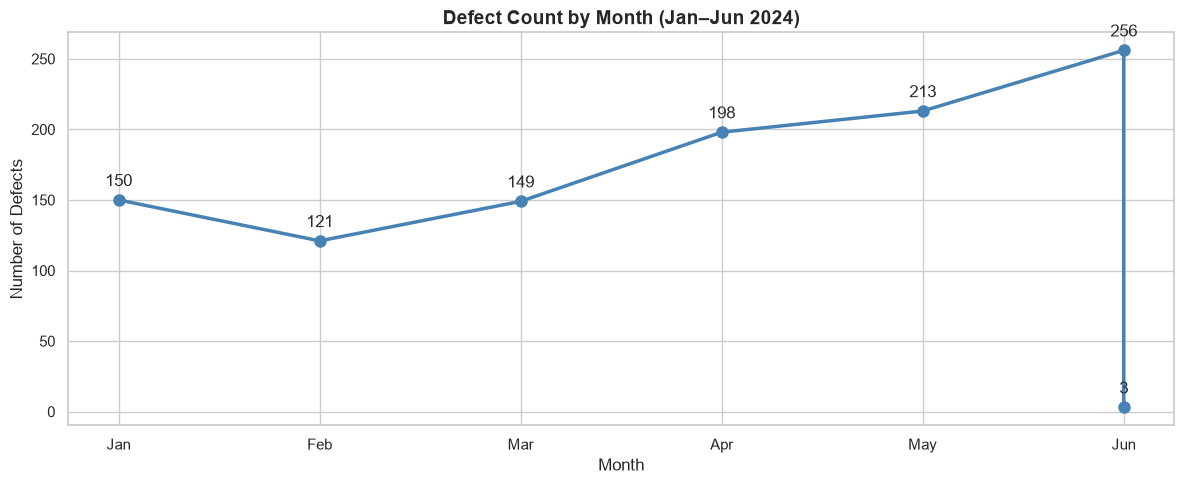

In [19]:
month_trend = (df.groupby(['year', 'month', 'month_name'])
                 .size()
                 .reset_index(name='defect_count')
                 .sort_values('month'))

fig, ax = plt.subplots()
ax.plot(month_trend['month_name'], month_trend['defect_count'],
        marker='o', linewidth=2.5, color='steelblue', markersize=8)

# Annotate từng điểm
for _, row in month_trend.iterrows():
    ax.annotate(f"{int(row['defect_count'])}",
                xy=(row['month_name'], row['defect_count']),
                xytext=(0, 10), textcoords='offset points', ha='center')

ax.set_title('Defect Count by Month (Jan–Jun 2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Defects')
plt.tight_layout()
plt.savefig('trend_monthly.png', dpi=150)
plt.show()

# Cell 10 — Trend theo từng production line


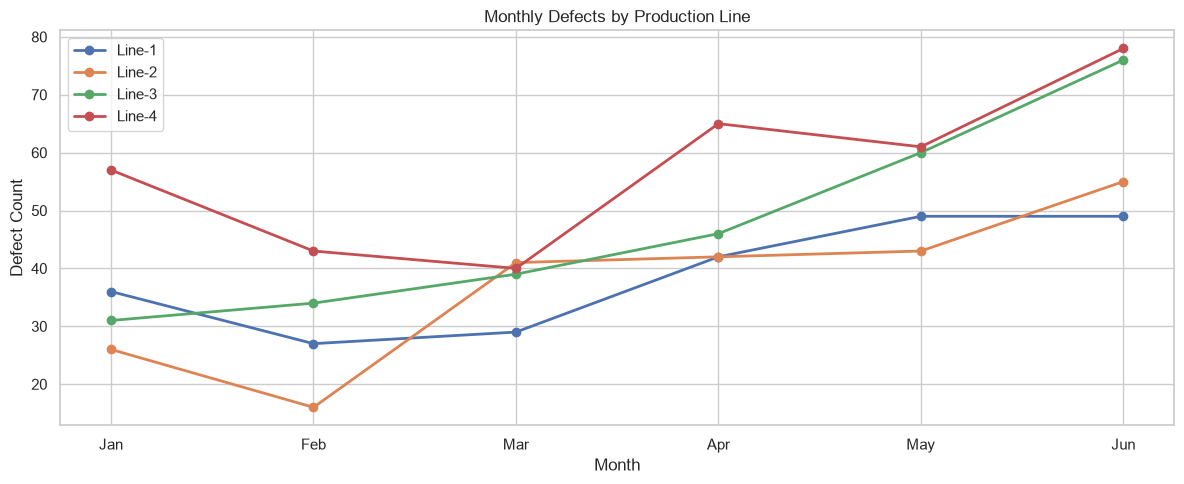

In [20]:
line_month = (df.groupby(['production_line', 'month_name', 'month'])
                .size()
                .reset_index(name='count')
                .sort_values('month'))

fig, ax = plt.subplots()
for line, group in line_month.groupby('production_line'):
    ax.plot(group['month_name'], group['count'], marker='o', label=line, linewidth=2)

ax.set_title('Monthly Defects by Production Line')
ax.set_xlabel('Month')
ax.set_ylabel('Defect Count')
ax.legend()
plt.tight_layout()
plt.show()

# Cell 11 — Tính tốc độ thay đổi (MoM % change)


In [21]:
month_trend['mom_change'] = month_trend['defect_count'].pct_change() * 100
print("Month-over-Month Change:")
print(month_trend[['month_name', 'defect_count', 'mom_change']].to_string(index=False))

Month-over-Month Change:
month_name  defect_count  mom_change
       Jan           150         NaN
       Feb           121  -19.333333
       Mar           149   23.140496
       Apr           198   32.885906
       May           213    7.575758
       Jun           256   20.187793
       Jun             3  -98.828125


# Cell 12 — Phân bố defect location


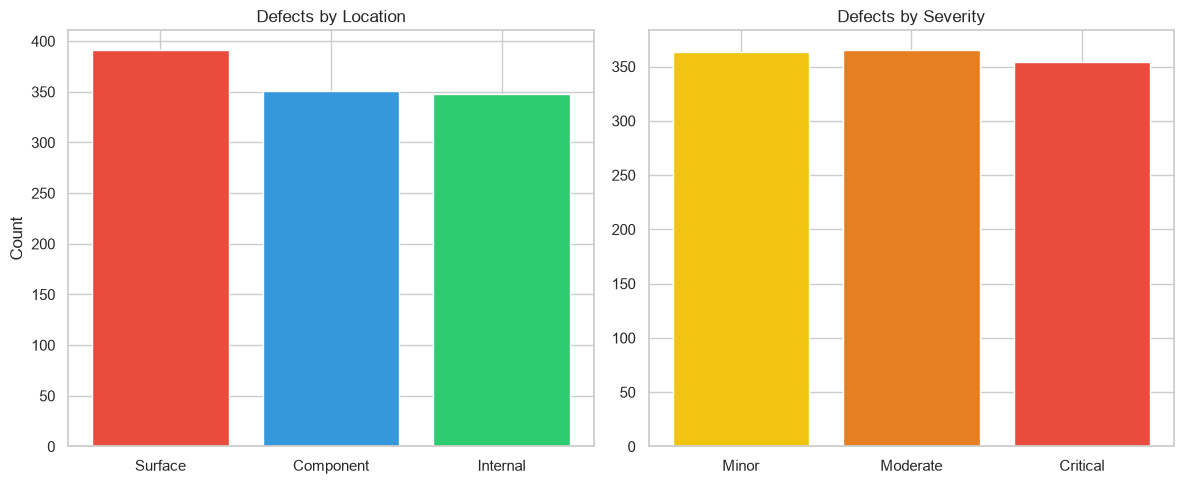

In [22]:
fig, axes = plt.subplots(1, 2)

# Count by location
loc_counts = df['defect_location'].value_counts()
axes[0].bar(loc_counts.index, loc_counts.values, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Defects by Location')
axes[0].set_ylabel('Count')

# Count by severity
sev_counts = df['severity'].value_counts().reindex(['Minor', 'Moderate', 'Critical'])
axes[1].bar(sev_counts.index, sev_counts.values, color=['#f1c40f', '#e67e22', '#e74c3c'])
axes[1].set_title('Defects by Severity')

plt.tight_layout()
plt.show()

# Cell 13 — Heatmap Location × Severity (câu hỏi cốt lõi)


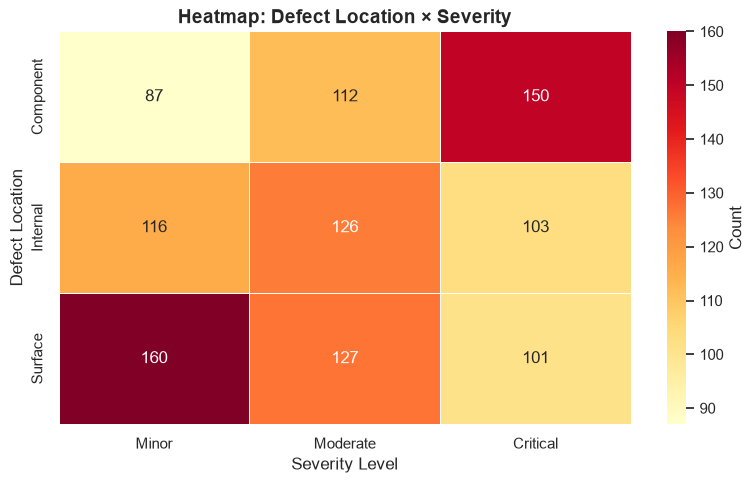

In [23]:
cross = pd.crosstab(df['defect_location'], df['severity'])
# Reorder severity columns
cross = cross[['Minor', 'Moderate', 'Critical']]

plt.figure(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Heatmap: Defect Location × Severity', fontsize=14, fontweight='bold')
plt.ylabel('Defect Location')
plt.xlabel('Severity Level')
plt.tight_layout()
plt.savefig('heatmap_location_severity.png', dpi=150)
plt.show()

# Cell 14 — Chi-square test: location và severity có liên quan không?


In [24]:
contingency = pd.crosstab(df['defect_location'], df['severity'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print()
if p_value < 0.05:
    print("✅ Kết luận: Có mối quan hệ thống kê giữa defect location và severity (p < 0.05)")
else:
    print("❌ Kết luận: Không có đủ bằng chứng thống kê về mối quan hệ (p >= 0.05)")

Chi-square statistic: 39.1914
P-value: 0.0001
Degrees of freedom: 12

✅ Kết luận: Có mối quan hệ thống kê giữa defect location và severity (p < 0.05)


# Cell 15 — Repair cost phân bố theo severity


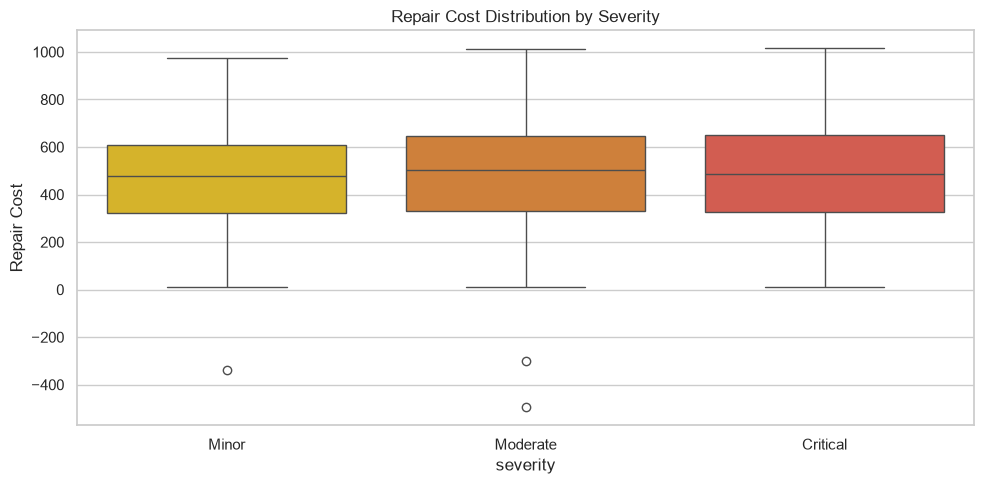

          count    mean     std     min     25%     50%     75%      max
severity                                                                
Critical  347.0  488.24  222.13   10.00  324.50  486.77  648.93  1014.75
MINOR       0.0     NaN     NaN     NaN     NaN     NaN     NaN      NaN
MODERATE    2.0  438.21  111.68  359.24  398.72  438.21  477.69   517.18
Minor     360.0  473.59  209.45 -338.00  321.79  478.18  607.05   973.13
Moderate  357.0  486.48  225.87 -495.29  330.98  504.46  646.24  1013.15
critical    1.0  308.89     NaN  308.89  308.89  308.89  308.89   308.89
minor       3.0  643.01   93.33  555.62  593.86  632.09  686.70   741.32


In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='severity', y='repair_cost',
            order=['Minor', 'Moderate', 'Critical'],
            palette=['#f1c40f', '#e67e22', '#e74c3c'])
plt.title('Repair Cost Distribution by Severity')
plt.ylabel('Repair Cost')
plt.tight_layout()
plt.show()

print(df.groupby('severity')['repair_cost'].describe().round(2))

# Cell 16 — Top 10 sản phẩm nhiều lỗi nhất


In [26]:
top_products = (df.groupby(['product_id', 'product_name', 'production_line'])
                  .agg(defect_count=('defect_id', 'count'),
                       avg_repair_cost=('repair_cost', 'mean'),
                       total_repair_cost=('repair_cost', 'sum'))
                  .reset_index()
                  .sort_values('defect_count', ascending=False)
                  .head(10))

print(top_products.to_string(index=False))

 product_id product_name production_line  defect_count  avg_repair_cost  total_repair_cost
         81   Product CC          Line-2            36       498.160278           17933.77
         83   Product CE          Line-2            26       567.202800           14180.07
         82   Product CD          Line-1            24       510.130417           12243.13
         84   Product CF          Line-4            22       540.009524           11340.20
         97   Product CS          Line-4            20       331.492222            5966.86
         63   Product BK          Line-4            20       453.501579            8616.53
         85   Product CG          Line-3            19       640.507895           12169.65
         56   Product BD          Line-4            18       353.368824            6007.27
         10    Product J          Line-1            17       475.546471            8084.29
          4    Product D          Line-1            16       365.923750            5854.78

# Cell 17 — Anomaly detection: tháng nào bất thường?


In [27]:
monthly = df.groupby('month').size().reset_index(name='count')
mean = monthly['count'].mean()
std = monthly['count'].std()

monthly['z_score'] = (monthly['count'] - mean) / std
monthly['is_anomaly'] = monthly['z_score'].abs() > 1.5

print("Phát hiện anomaly (|z| > 1.5):")
print(monthly[['month', 'count', 'z_score', 'is_anomaly']].to_string(index=False))

Phát hiện anomaly (|z| > 1.5):
 month  count   z_score  is_anomaly
     1    150 -0.621529       False
     2    121 -1.190718       False
     3    149 -0.641156       False
     4    198  0.320578       False
     5    213  0.614986       False
     6    259  1.517838        True


# Cell 18 — Defect type theo production line (heatmap thứ hai)


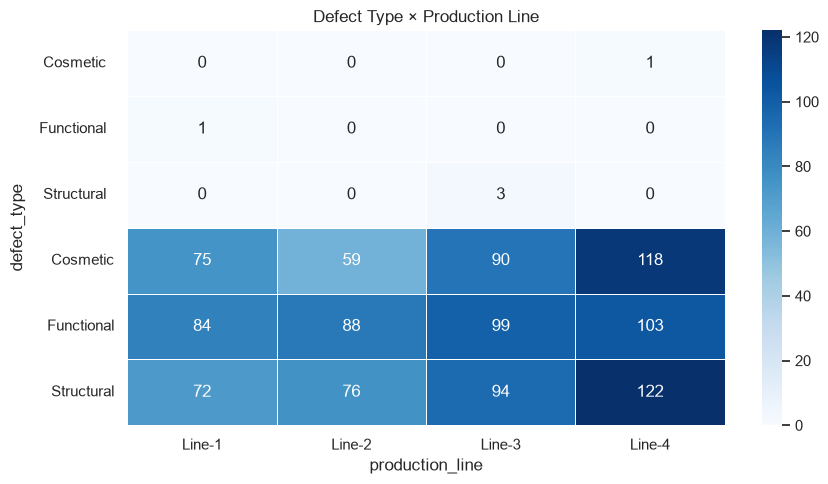

In [28]:
type_line = pd.crosstab(df['defect_type'], df['production_line'])

plt.figure(figsize=(9, 5))
sns.heatmap(type_line, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Defect Type × Production Line')
plt.tight_layout()
plt.show()

# Cell 19 — In tất cả insights tổng hợp


In [29]:
print("=" * 60)
print("SUMMARY INSIGHTS")
print("=" * 60)

print(f"\n📊 Tổng số defect records: {len(df)}")
print(f"📦 Số sản phẩm: {df['product_id'].nunique()}")
print(f"🏭 Số production lines: {df['production_line'].nunique()}")
print(f"📅 Thời gian: {df['defect_date'].min().date()} → {df['defect_date'].max().date()}")

print(f"\n💰 Tổng repair cost: {df['repair_cost'].sum():,.0f}")
print(f"💰 Avg repair cost/defect: {df['repair_cost'].mean():,.0f}")

print(f"\n🔴 Line nhiều lỗi nhất: {df['production_line'].value_counts().idxmax()}")
print(f"⚠️  Severity phổ biến nhất: {df['severity'].value_counts().idxmax()}")
print(f"📍 Location lỗi nhiều nhất: {df['defect_location'].value_counts().idxmax()}")

SUMMARY INSIGHTS

📊 Tổng số defect records: 1090
📦 Số sản phẩm: 105
🏭 Số production lines: 4
📅 Thời gian: 2024-01-01 → 2026-06-20

💰 Tổng repair cost: 516,699
💰 Avg repair cost/defect: 483

🔴 Line nhiều lỗi nhất: Line-4
⚠️  Severity phổ biến nhất: Moderate
📍 Location lỗi nhiều nhất: Surface
